# OW Yellow Caps — Notebook 3: Bivariate EDA

**Client:** OW Yellow Caps  
**Data:** NYC TLC Yellow Taxi · Jan–Mar 2025 (post-cleaning)  
**Purpose:** Two-variable relationships to uncover operational patterns.

## Coverage (per TOR §6.2)
- Hour of day vs trip volume
- Weekday vs demand
- Geography vs revenue / trip count
- Payment type vs tip / total amount
- Distance vs total amount
- Pre/post CBD congestion fee analysis
- Vendor vs trip metrics
- Rate code vs fare

**Visualization principles** applied: scatter plots, grouped bar charts, violin plots,
heatmaps, line charts — matched to data types as per the course *Data Visualisation Cookbook* slides.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.titleweight': 'bold'})

CLEAN_PATH = 'yellow_taxi_clean.parquet'

df = pd.read_parquet(CLEAN_PATH)
print(f'Loaded: {len(df):,} rows × {df.shape[1]} columns')

# Constant mappings
PT_LABELS = {0: 'Flex Fare', 1: 'Credit Card', 2: 'Cash',
             3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
VENDOR_LABELS = {1: 'Creative Mobile', 2: 'Curb Mobility',
                 6: 'Myle Technologies', 7: 'Helix'}
RATE_LABELS = {1.0: 'Standard', 2.0: 'JFK', 3.0: 'Newark',
               4.0: 'Nassau/WC', 5.0: 'Negotiated', 6.0: 'Group', 99.0: 'Unknown'}
DOW_ORDER   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
print('Setup complete.')

Loaded: 10,448,657 rows × 33 columns
Setup complete.


---
## 1. Hour of Day vs Trip Volume

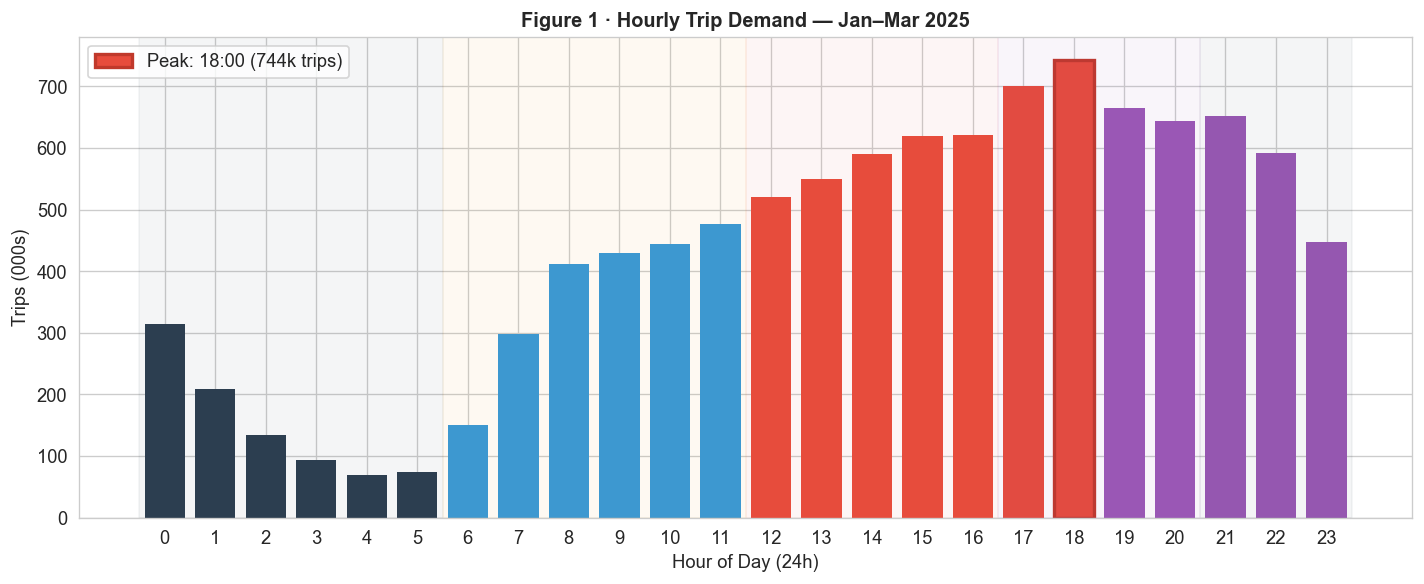

Top 5 hours by trip volume:
 pickup_hour  trips
          18 743609
          17 699881
          19 664709
          21 652593
          20 643040


In [4]:
hourly = df.groupby('pickup_hour').size().reset_index(name='trips')

fig, ax = plt.subplots(figsize=(12, 5))
colors_hour = ['#2c3e50' if h < 6 else '#3498db' if h < 12
               else '#e74c3c' if h < 18 else '#9b59b6' for h in hourly.pickup_hour]
bars = ax.bar(hourly.pickup_hour, hourly.trips / 1000, color=colors_hour, edgecolor='none')

# Annotate peak hour
peak_idx = hourly.trips.idxmax()
ax.bar(hourly.loc[peak_idx, 'pickup_hour'], hourly.loc[peak_idx, 'trips'] / 1000,
       color='#e74c3c', edgecolor='#c0392b', linewidth=2,
       label=f"Peak: {hourly.loc[peak_idx,'pickup_hour']}:00 ({hourly.loc[peak_idx,'trips']/1000:.0f}k trips)")

# Shade time-of-day bands
for start, end, label, c in [(0,6,'Night','#2c3e50'),(6,12,'Morning','#f39c12'),
                               (12,17,'Afternoon','#e74c3c'),(17,21,'Evening','#8e44ad'),
                               (21,24,'Late Night','#2c3e50')]:
    ax.axvspan(start-0.5, end-0.5, alpha=0.05, color=c)

ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('Trips (000s)')
ax.set_title('Figure 1 · Hourly Trip Demand — Jan–Mar 2025')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

print('Top 5 hours by trip volume:')
print(hourly.nlargest(5, 'trips').to_string(index=False))

---
## 2. Weekday vs Trip Demand

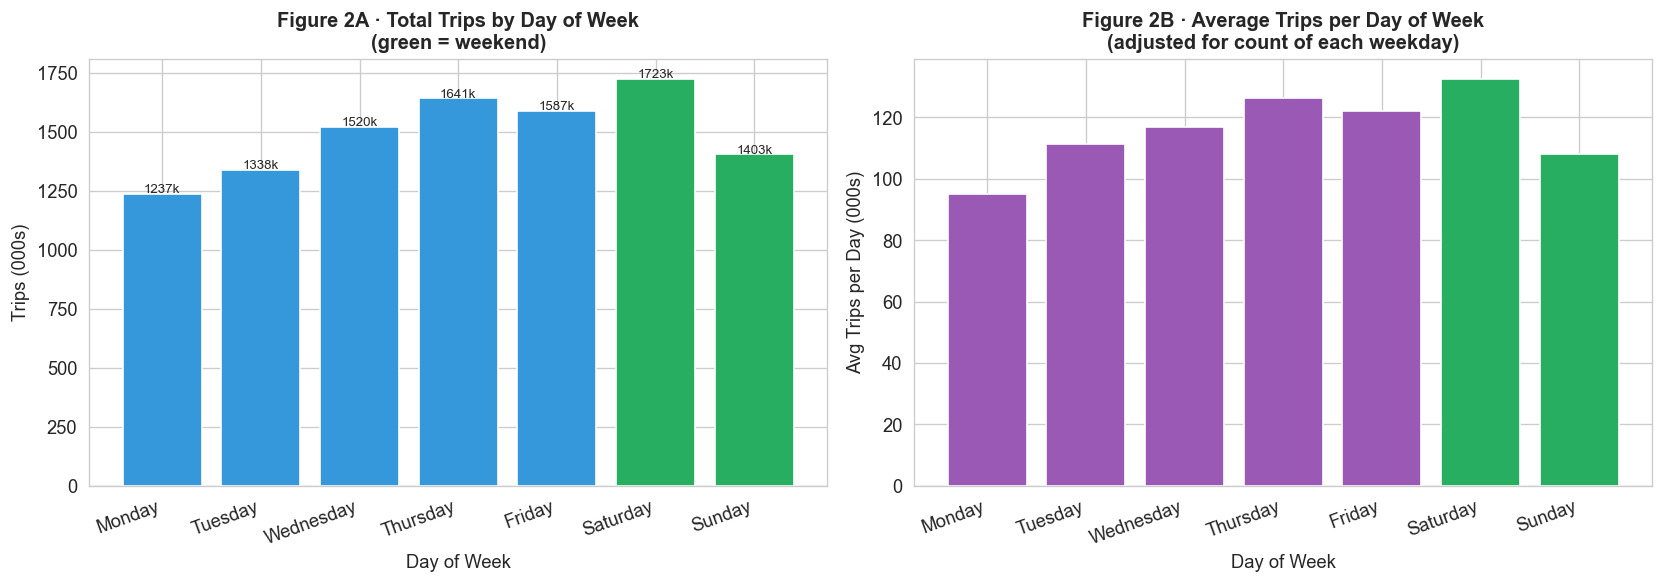

In [5]:
dow_trips = df.groupby('pickup_dow_name').size().reindex(DOW_ORDER).reset_index()
dow_trips.columns = ['day', 'trips']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of total trips
colors_dow = ['#27ae60' if d in ('Saturday', 'Sunday') else '#3498db' for d in dow_trips.day]
axes[0].bar(dow_trips.day, dow_trips.trips / 1000, color=colors_dow, edgecolor='white')
for i, row in dow_trips.iterrows():
    axes[0].text(i, row.trips/1000 + 5, f'{row.trips/1000:.0f}k', ha='center', fontsize=8)
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Trips (000s)')
axes[0].set_title('Figure 2A · Total Trips by Day of Week\n(green = weekend)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha='right')

# Average trips per day-of-week (per number of that weekday in the period)
# Count occurrences of each weekday in Jan-Mar 2025
all_dates = pd.date_range('2025-01-01', '2025-03-31')
dow_occurrences = pd.Series(all_dates.day_name()).value_counts()[DOW_ORDER]
dow_avg = (dow_trips.set_index('day')['trips'] / dow_occurrences).reindex(DOW_ORDER)

colors_avg = ['#27ae60' if d in ('Saturday', 'Sunday') else '#9b59b6' for d in DOW_ORDER]
axes[1].bar(DOW_ORDER, dow_avg / 1000, color=colors_avg, edgecolor='white')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Avg Trips per Day (000s)')
axes[1].set_title('Figure 2B · Average Trips per Day of Week\n(adjusted for count of each weekday)')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

---
## 3. Geography vs Trip Count & Revenue

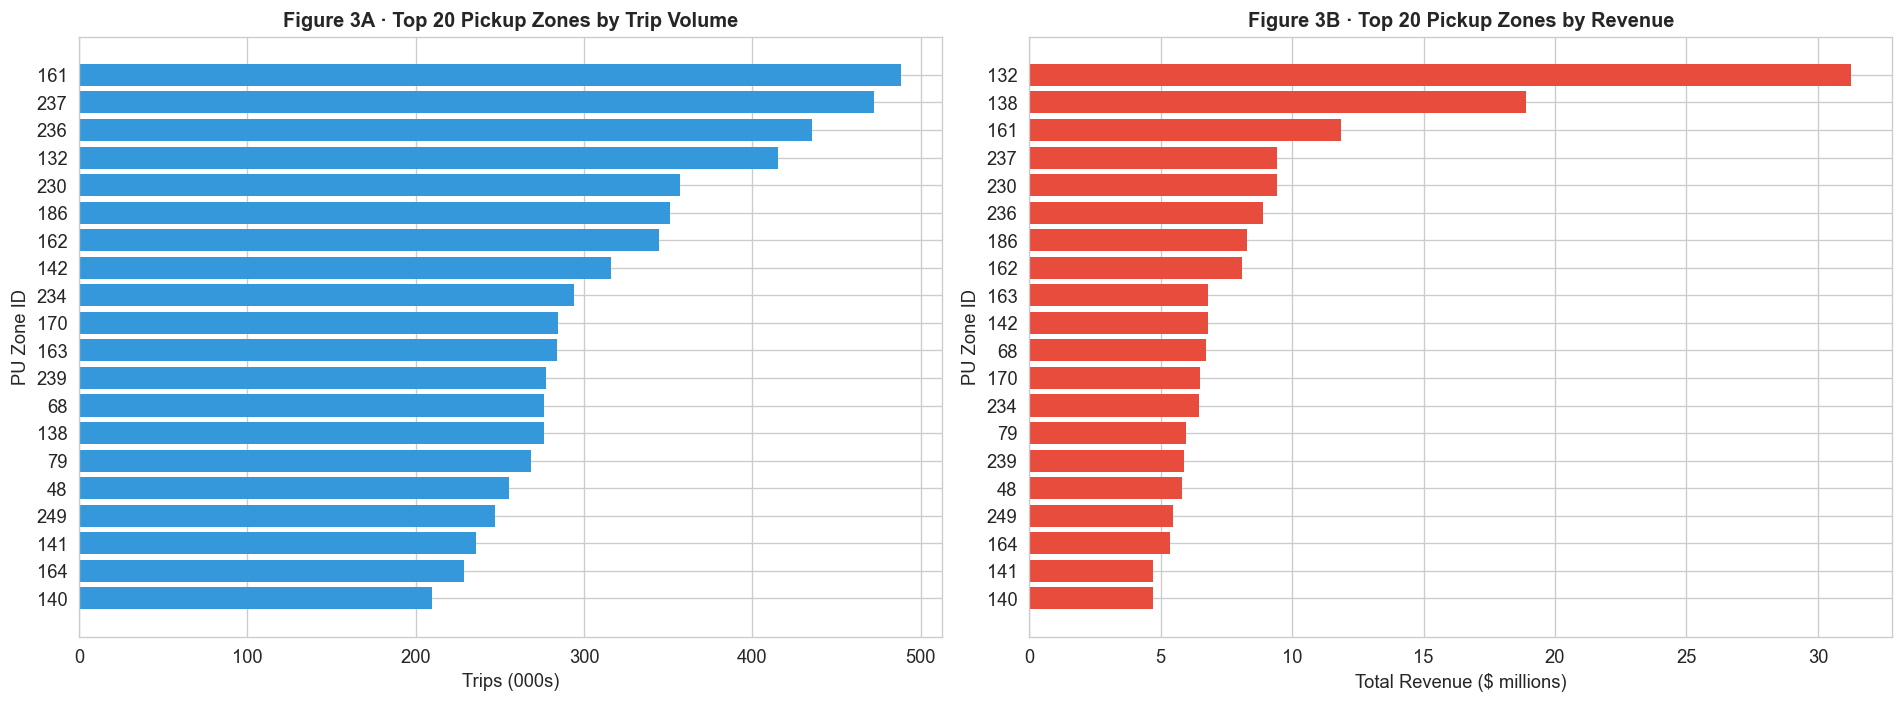

Top 10 zones by trips:
 PULocationID  trips  total_revenue  avg_fare
          161 488429    11842879.90     15.41
          237 472352     9439674.07     12.36
          236 435259     8902055.57     13.01
          132 415394    31269463.54     57.85
          230 356827     9415606.66     17.19
          186 351205     8279987.44     15.21
          162 344700     8103838.57     14.72
          142 315847     6809665.50     13.69
          234 294017     6449980.10     13.80
          170 284803     6489829.88     14.50


In [6]:
# Top 20 pickup zones by volume
pu_zone_vol  = df.groupby('PULocationID').agg(
    trips=('trip_id', 'count'),
    total_revenue=('total_amount', 'sum'),
    avg_fare=('fare_amount', 'mean')
).reset_index().sort_values('trips', ascending=False)

top20_pu = pu_zone_vol.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 zones by trips
axes[0].barh(top20_pu.PULocationID.astype(str).iloc[::-1],
             top20_pu.trips.iloc[::-1] / 1000,
             color='#3498db', edgecolor='none')
axes[0].set_xlabel('Trips (000s)')
axes[0].set_ylabel('PU Zone ID')
axes[0].set_title('Figure 3A · Top 20 Pickup Zones by Trip Volume')

# Top 20 zones by revenue
top20_rev = pu_zone_vol.sort_values('total_revenue', ascending=False).head(20)
axes[1].barh(top20_rev.PULocationID.astype(str).iloc[::-1],
             top20_rev.total_revenue.iloc[::-1] / 1e6,
             color='#e74c3c', edgecolor='none')
axes[1].set_xlabel('Total Revenue ($ millions)')
axes[1].set_ylabel('PU Zone ID')
axes[1].set_title('Figure 3B · Top 20 Pickup Zones by Revenue')

plt.tight_layout()
plt.show()

print('Top 10 zones by trips:')
print(top20_pu[['PULocationID','trips','total_revenue','avg_fare']].head(10).round(2).to_string(index=False))

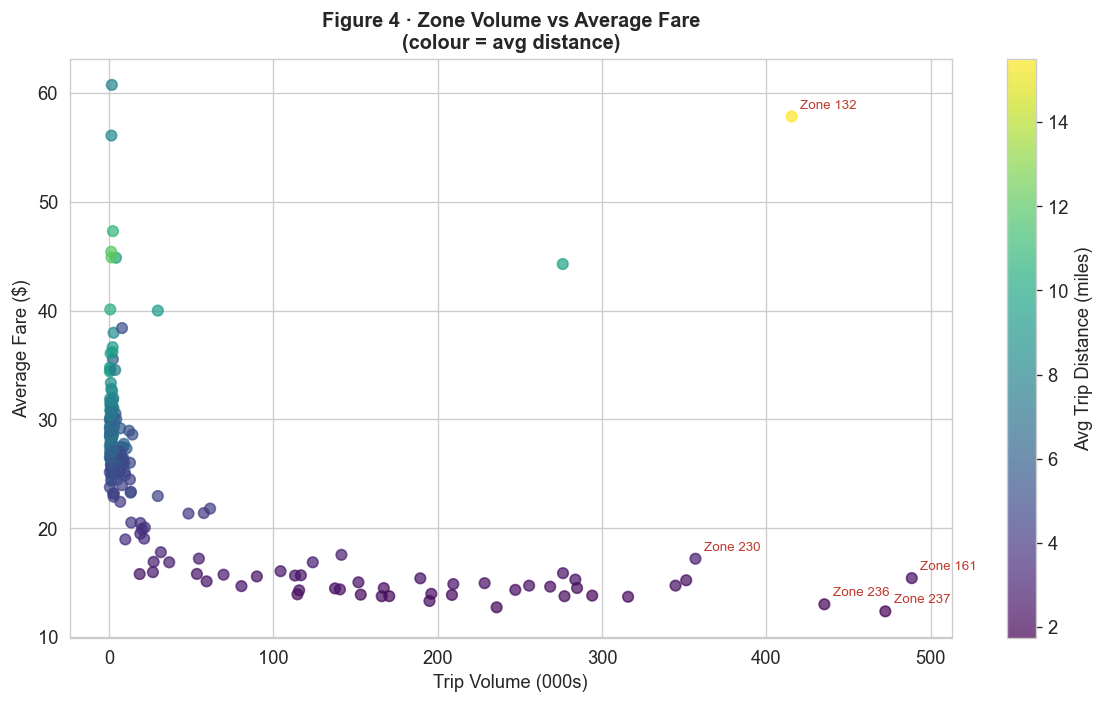

In [7]:
# ── Zone trip count vs avg fare scatter (revenue intelligence) ────────────
zone_stats = df.groupby('PULocationID').agg(
    trips=('trip_id', 'count'),
    avg_fare=('fare_amount', 'mean'),
    avg_dist=('trip_distance', 'mean')
).reset_index()
# Filter zones with at least 500 trips
zone_stats = zone_stats[zone_stats.trips >= 500]

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(zone_stats.trips / 1000, zone_stats.avg_fare,
                     c=zone_stats.avg_dist, cmap='viridis',
                     alpha=0.7, s=40)
plt.colorbar(scatter, label='Avg Trip Distance (miles)')

# Highlight top-volume zones
top5 = zone_stats.nlargest(5, 'trips')
for _, row in top5.iterrows():
    ax.annotate(f'Zone {int(row.PULocationID)}',
                (row.trips/1000, row.avg_fare),
                fontsize=8, color='#c0392b',
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Trip Volume (000s)')
ax.set_ylabel('Average Fare ($)')
ax.set_title('Figure 4 · Zone Volume vs Average Fare\n(colour = avg distance)')
plt.tight_layout()
plt.show()

---
## 4. Payment Type vs Tip & Total Amount

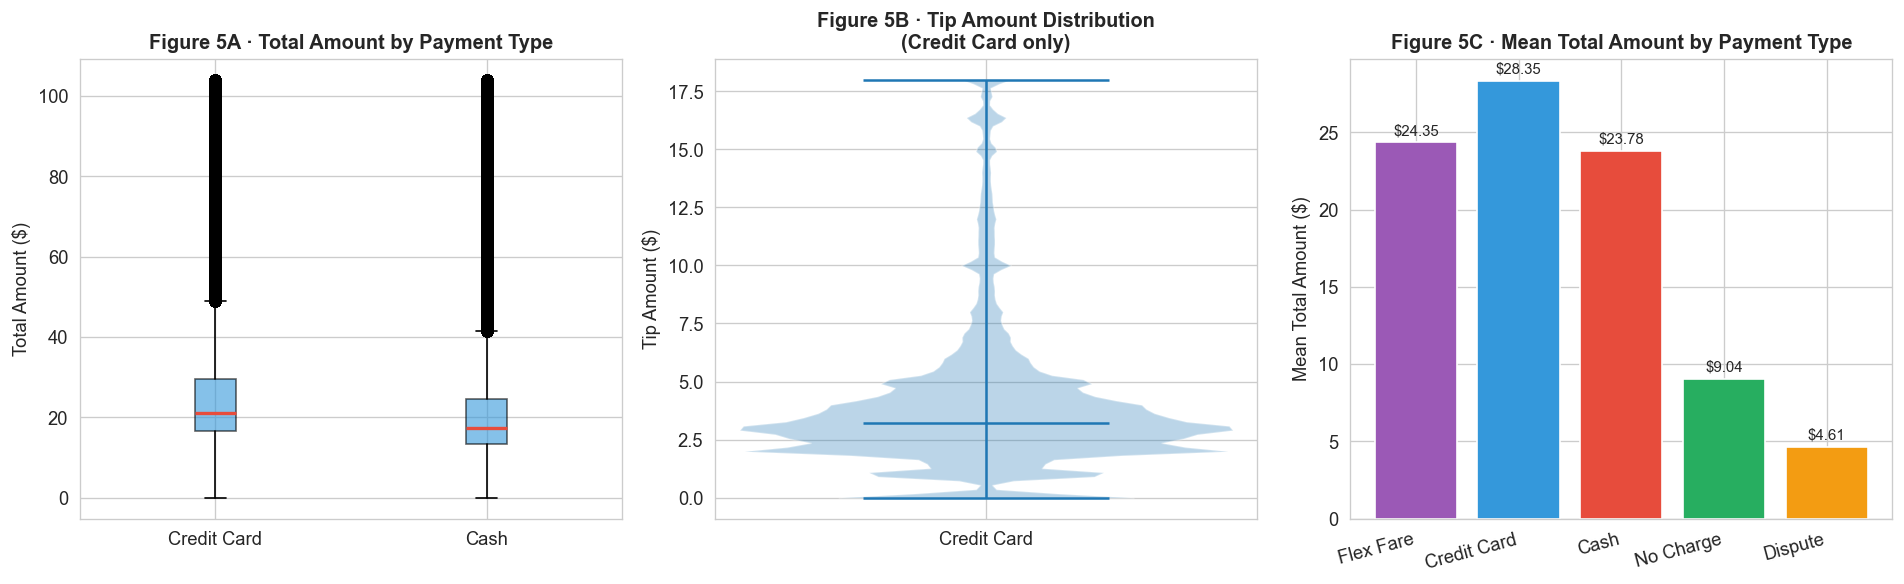

Mean total amount by payment type:
               mean  median
payment_type               
Cash          23.78   17.25
Credit Card   28.35   21.06
Dispute        4.61    7.75
Flex Fare     24.35   21.67
No Charge      9.04   11.55


In [8]:
# Focus on Credit Card vs Cash (main payment types)
df_main_pt = df[df.payment_type.isin([1, 2])].copy()
df_main_pt['payment_label'] = df_main_pt.payment_type.map({1: 'Credit Card', 2: 'Cash'})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Box plot: total_amount by payment type
cap_total = df_main_pt.total_amount.quantile(0.99)
plot_data = {pt: df_main_pt[df_main_pt.payment_label == pt]['total_amount'].clip(upper=cap_total)
             for pt in ['Credit Card', 'Cash']}

axes[0].boxplot([plot_data['Credit Card'], plot_data['Cash']],
                labels=['Credit Card', 'Cash'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6),
                medianprops=dict(color='#e74c3c', linewidth=2))
axes[0].set_ylabel('Total Amount ($)')
axes[0].set_title('Figure 5A · Total Amount by Payment Type')

# Violin: tip_amount for credit card only (meaningful)
tip_cc = df[df.payment_type == 1]['tip_amount'].clip(upper=df[df.payment_type==1]['tip_amount'].quantile(0.99))
axes[1].violinplot(tip_cc, positions=[1], widths=0.6, showmedians=True)
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Credit Card'])
axes[1].set_ylabel('Tip Amount ($)')
axes[1].set_title('Figure 5B · Tip Amount Distribution\n(Credit Card only)')

# Bar: mean total_amount by all payment types
pt_means = df[df.payment_type.isin([0,1,2,3,4])].groupby('payment_type')['total_amount'].mean()
pt_labels_plot = pt_means.index.map(PT_LABELS)
axes[2].bar(pt_labels_plot, pt_means.values,
            color=['#9b59b6','#3498db','#e74c3c','#27ae60','#f39c12'])
for i, v in enumerate(pt_means.values):
    axes[2].text(i, v + 0.5, f'${v:.2f}', ha='center', fontsize=9)
axes[2].set_ylabel('Mean Total Amount ($)')
axes[2].set_title('Figure 5C · Mean Total Amount by Payment Type')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

print('Mean total amount by payment type:')
print(df.groupby(df.payment_type.map(PT_LABELS))['total_amount'].agg(['mean','median']).round(2))

---
## 5. Trip Distance vs Total Amount

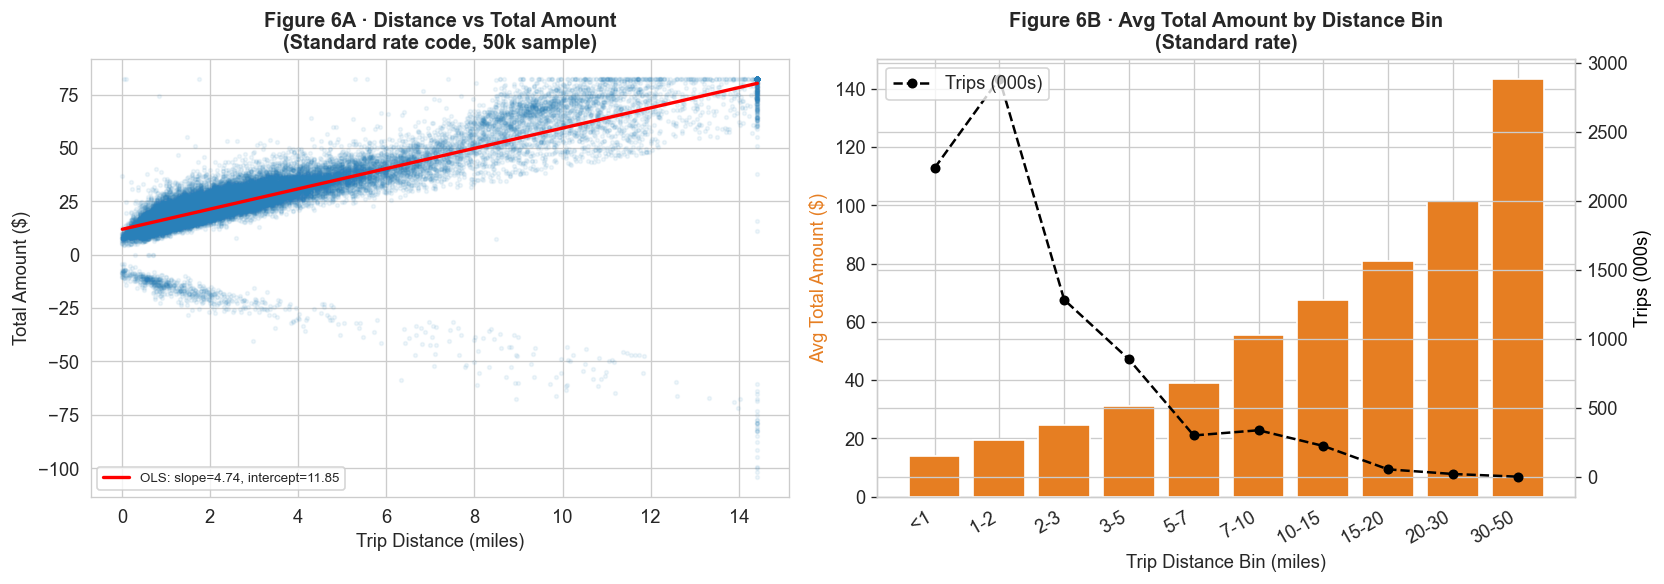

In [9]:
# Sample for scatter plot performance
sample = df[(df.RatecodeID == 1.0)].sample(min(50_000, len(df)), random_state=42)
dist_cap = sample.trip_distance.quantile(0.99)
fare_cap = sample.total_amount.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(sample.trip_distance.clip(upper=dist_cap),
                sample.total_amount.clip(upper=fare_cap),
                alpha=0.07, s=5, color='#2980b9')
# Add regression line
from numpy.polynomial import polynomial as P
x = sample.trip_distance.clip(upper=dist_cap).dropna()
y = sample.total_amount.clip(upper=fare_cap).loc[x.index]
coefs = np.polyfit(x, y, 1)
xfit = np.linspace(x.min(), x.max(), 100)
axes[0].plot(xfit, np.polyval(coefs, xfit), 'r-', lw=2,
             label=f'OLS: slope={coefs[0]:.2f}, intercept={coefs[1]:.2f}')
axes[0].set_xlabel('Trip Distance (miles)')
axes[0].set_ylabel('Total Amount ($)')
axes[0].set_title('Figure 6A · Distance vs Total Amount\n(Standard rate code, 50k sample)')
axes[0].legend(fontsize=8)

# Distance bins vs avg total amount
bins = [0, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50]
labels_bin = ['<1', '1-2', '2-3', '3-5', '5-7', '7-10', '10-15', '15-20', '20-30', '30-50']
df_std = df[df.RatecodeID == 1.0].copy()
df_std['dist_bin'] = pd.cut(df_std.trip_distance, bins=bins, labels=labels_bin)
bin_stats = df_std.groupby('dist_bin', observed=True).agg(
    trips=('trip_id', 'count'),
    avg_total=('total_amount', 'mean')
)

ax2 = axes[1]
bars = ax2.bar(bin_stats.index, bin_stats.avg_total,
               color='#e67e22', edgecolor='white')
ax2b = ax2.twinx()
ax2b.plot(range(len(bin_stats)), bin_stats.trips / 1000, 'ko--',
          markersize=5, label='Trips (000s)')
ax2.set_xlabel('Trip Distance Bin (miles)')
ax2.set_ylabel('Avg Total Amount ($)', color='#e67e22')
ax2b.set_ylabel('Trips (000s)', color='black')
ax2.set_title('Figure 6B · Avg Total Amount by Distance Bin\n(Standard rate)')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2b.legend(loc='upper left')

plt.tight_layout()
plt.show()

---
## 6. Pre vs Post CBD Congestion Fee (Jan 5, 2025)

=== Pre vs Post CBD Congestion Fee Comparison ===
                         Pre CBD\n(Jan 1–4)  Post CBD\n(Jan 5–Mar 31)  Change (%)
Avg Total Amount ($)                 27.141                    26.581       -2.06
Avg Fare Amount ($)                  18.739                    18.023       -3.82
Avg Trip Distance (mi)                3.594                     3.215      -10.55
Avg Trip Duration (min)              15.952                    15.631       -2.01


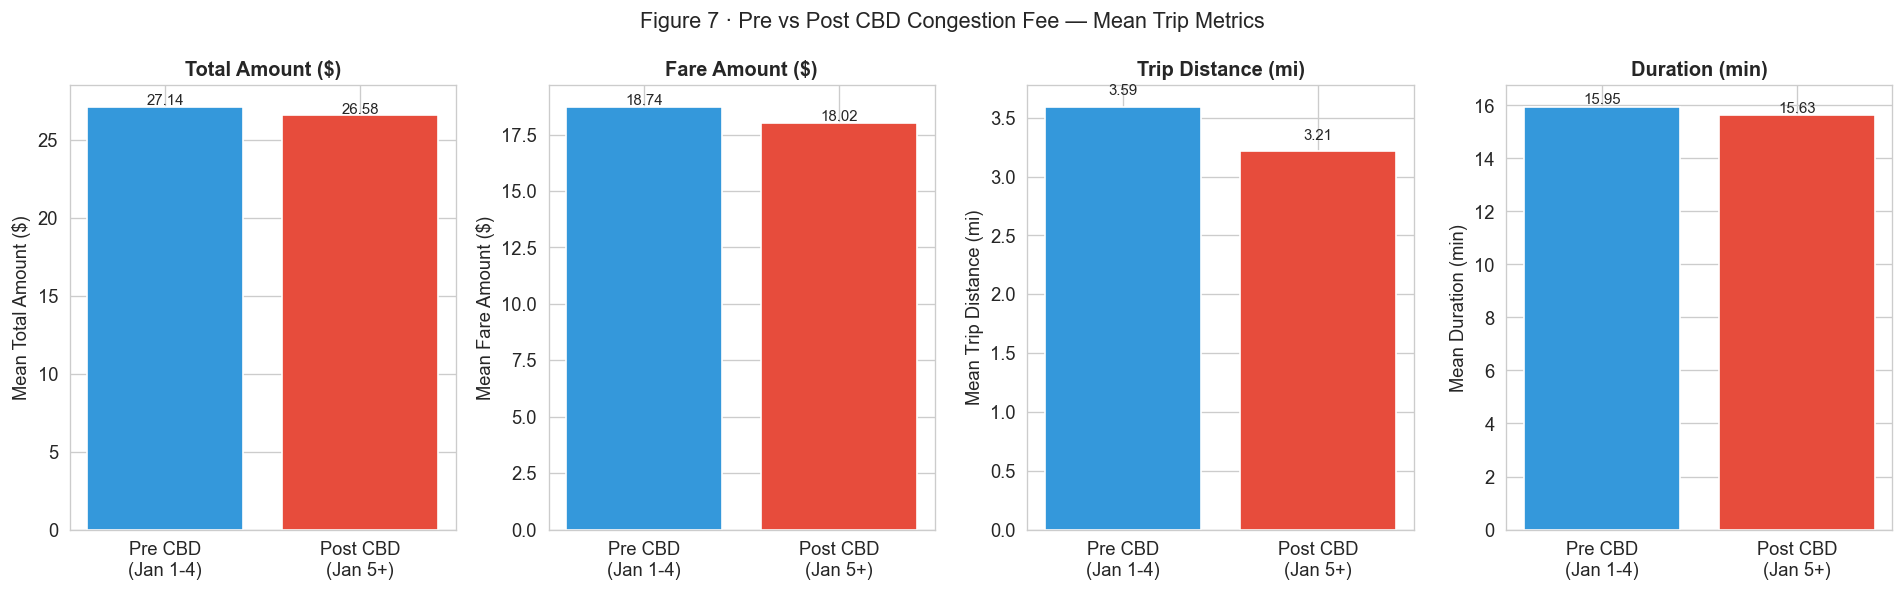

In [10]:
# Compare key metrics before and after CBD fee introduction
pre  = df[~df.is_post_cbd]
post = df[df.is_post_cbd]

metrics = {
    'Avg Total Amount ($)': ('total_amount', 'mean'),
    'Avg Fare Amount ($)':  ('fare_amount', 'mean'),
    'Avg Trip Distance (mi)': ('trip_distance', 'mean'),
    'Avg Trip Duration (min)': ('trip_duration_min', 'mean'),
}

comparison = pd.DataFrame({
    'Pre CBD\n(Jan 1–4)':  {k: pre[v[0]].agg(v[1]) for k, v in metrics.items()},
    'Post CBD\n(Jan 5–Mar 31)': {k: post[v[0]].agg(v[1]) for k, v in metrics.items()}
}).round(3)

comparison['Change (%)'] = (
    (comparison['Post CBD\n(Jan 5–Mar 31)'] - comparison['Pre CBD\n(Jan 1–4)'])
    / comparison['Pre CBD\n(Jan 1–4)'] * 100
).round(2)

print('=== Pre vs Post CBD Congestion Fee Comparison ===')
print(comparison.to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
cols_plot = ['total_amount', 'fare_amount', 'trip_distance', 'trip_duration_min']
labels_plot = ['Total Amount ($)', 'Fare Amount ($)', 'Trip Distance (mi)', 'Duration (min)']

for ax, col, label in zip(axes, cols_plot, labels_plot):
    pre_val  = pre[col].mean()
    post_val = post[col].mean()
    bars = ax.bar(['Pre CBD\n(Jan 1-4)', 'Post CBD\n(Jan 5+)'],
                  [pre_val, post_val],
                  color=['#3498db', '#e74c3c'], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{bar.get_height():.2f}', ha='center', fontsize=9)
    ax.set_ylabel(f'Mean {label}')
    ax.set_title(f'{label}')

fig.suptitle('Figure 7 · Pre vs Post CBD Congestion Fee — Mean Trip Metrics', fontsize=13)
plt.tight_layout()
plt.show()

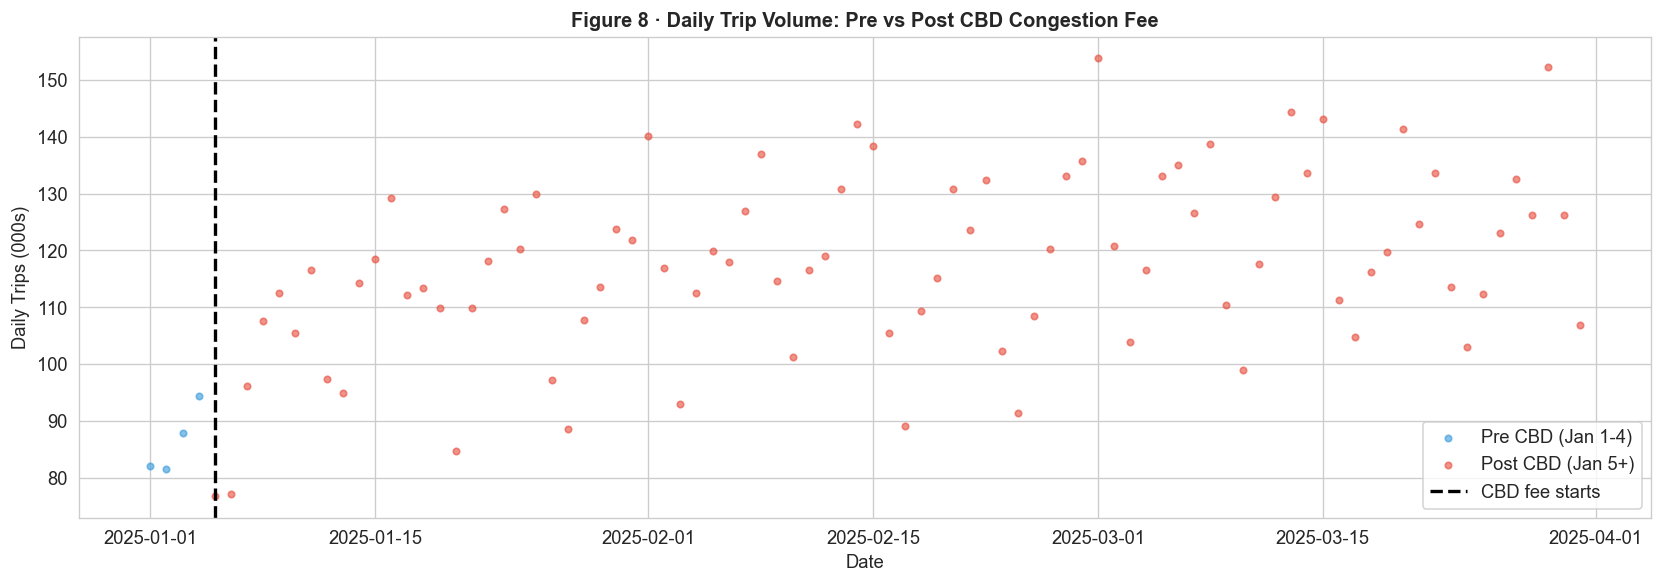

In [11]:
# ── Daily volume: pre vs post CBD ─────────────────────────────────────────
daily = df.groupby(['pickup_date', 'is_post_cbd']).size().reset_index(name='trips')
daily['pickup_date'] = pd.to_datetime(daily['pickup_date'])

fig, ax = plt.subplots(figsize=(14, 5))
for cbd, color, label in [(False, '#3498db', 'Pre CBD (Jan 1-4)'),
                           (True,  '#e74c3c', 'Post CBD (Jan 5+)')]:
    sub = daily[daily.is_post_cbd == cbd]
    ax.scatter(sub.pickup_date, sub.trips / 1000, alpha=0.6, s=15,
               color=color, label=label)

ax.axvline(pd.Timestamp('2025-01-05'), color='black', linestyle='--', lw=2, label='CBD fee starts')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Trips (000s)')
ax.set_title('Figure 8 · Daily Trip Volume: Pre vs Post CBD Congestion Fee')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Rate Code vs Fare Amount

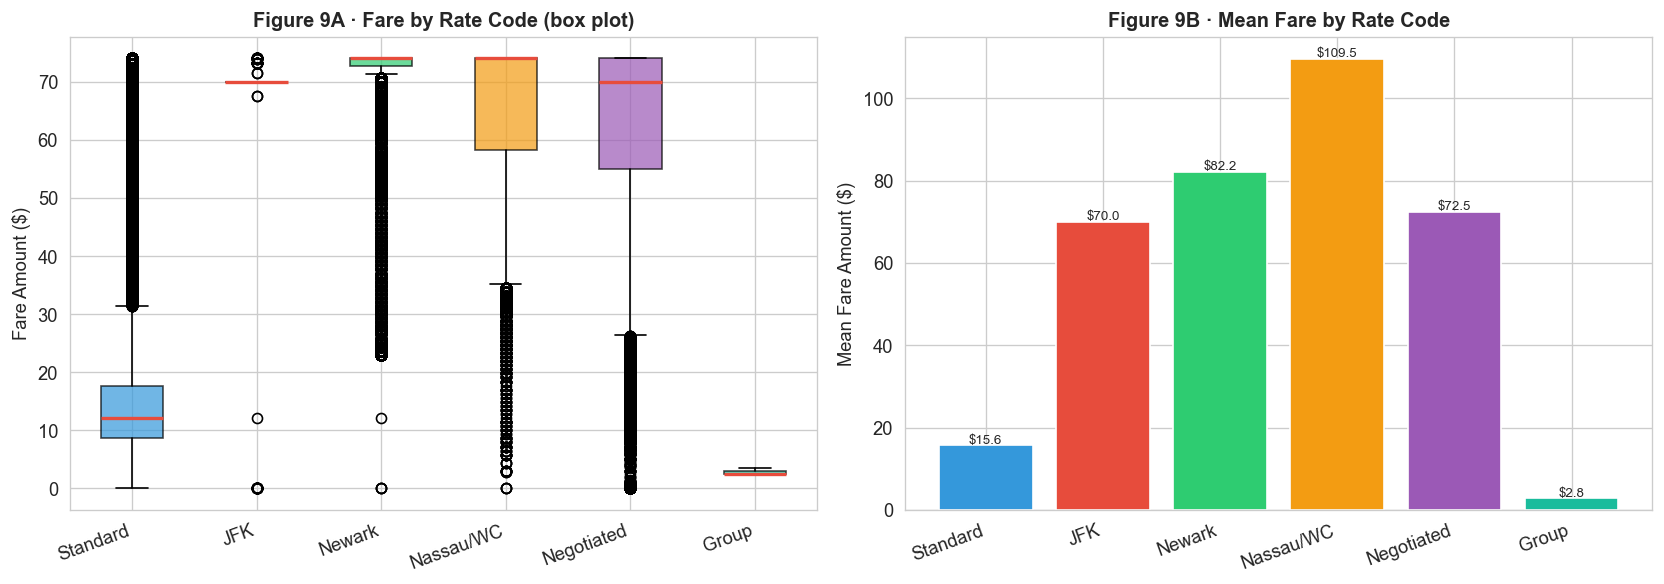

In [4]:
# Exclude Flex Fare (no RatecodeID) and negative fares (dispute/no-charge rows)
df_rate = df[(df.payment_type != 0) & (df.fare_amount >= 0)].copy()
df_rate['rate_label'] = df_rate.RatecodeID.map(RATE_LABELS)

# Only meaningful rate codes (exclude Unknown/99)
df_rate_m = df_rate[df_rate.RatecodeID != 99.0]
fare_cap = df_rate_m.fare_amount.quantile(0.99)

rate_order = ['Standard', 'JFK', 'Newark', 'Nassau/WC', 'Negotiated', 'Group']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of fare by rate code
data_by_rate = [df_rate_m[df_rate_m.rate_label == r]['fare_amount'].clip(lower=0, upper=fare_cap).dropna()
                for r in rate_order]
bp = axes[0].boxplot(data_by_rate, labels=rate_order, patch_artist=True,
                     medianprops=dict(color='#e74c3c', linewidth=2))
colors_rc = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c']
for patch, color in zip(bp['boxes'], colors_rc):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Fare Amount ($)')
axes[0].set_title('Figure 9A · Fare by Rate Code (box plot)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha='right')

# Mean fare and trip count by rate code
rate_summary = df_rate_m.groupby('rate_label').agg(
    trips=('trip_id', 'count'),
    avg_fare=('fare_amount', 'mean')
).reindex(rate_order)

ax_bar = axes[1]
bars = ax_bar.bar(rate_order, rate_summary.avg_fare, color=colors_rc, edgecolor='white')
for bar in bars:
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'${bar.get_height():.1f}', ha='center', fontsize=8)
ax_bar.set_ylabel('Mean Fare Amount ($)')
ax_bar.set_title('Figure 9B · Mean Fare by Rate Code')
plt.setp(ax_bar.xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

---
## 8. Hourly Demand Heatmap: Weekday × Hour

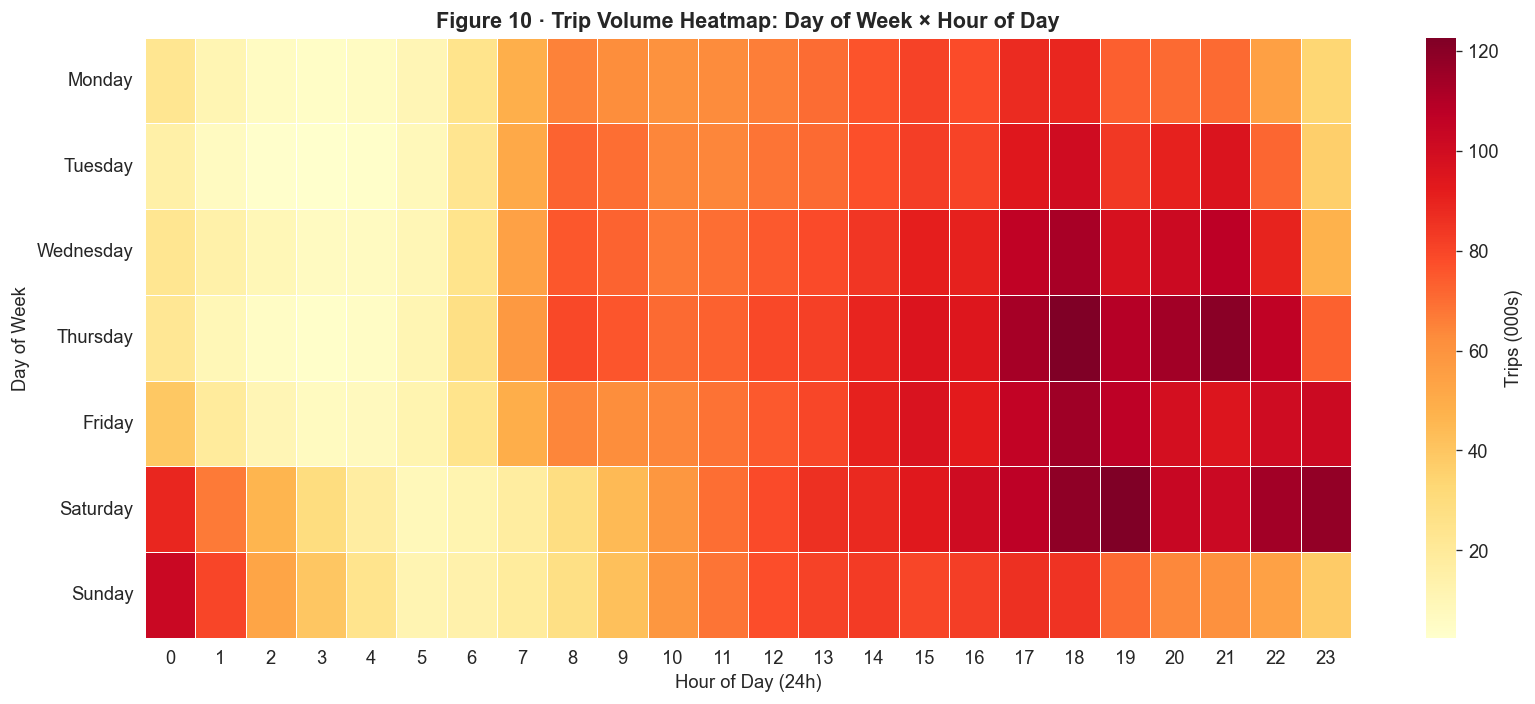

Peak demand: Friday evening is the busiest period.


In [13]:
heatmap_data = df.groupby(['pickup_dow_name', 'pickup_hour']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(DOW_ORDER)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data / 1000, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Trips (000s)'})
ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('Day of Week')
ax.set_title('Figure 10 · Trip Volume Heatmap: Day of Week × Hour of Day', fontsize=13)
plt.tight_layout()
plt.show()
print('Peak demand: Friday evening is the busiest period.')

---
## 9. Tip Rate vs Payment Type & Fare Bins

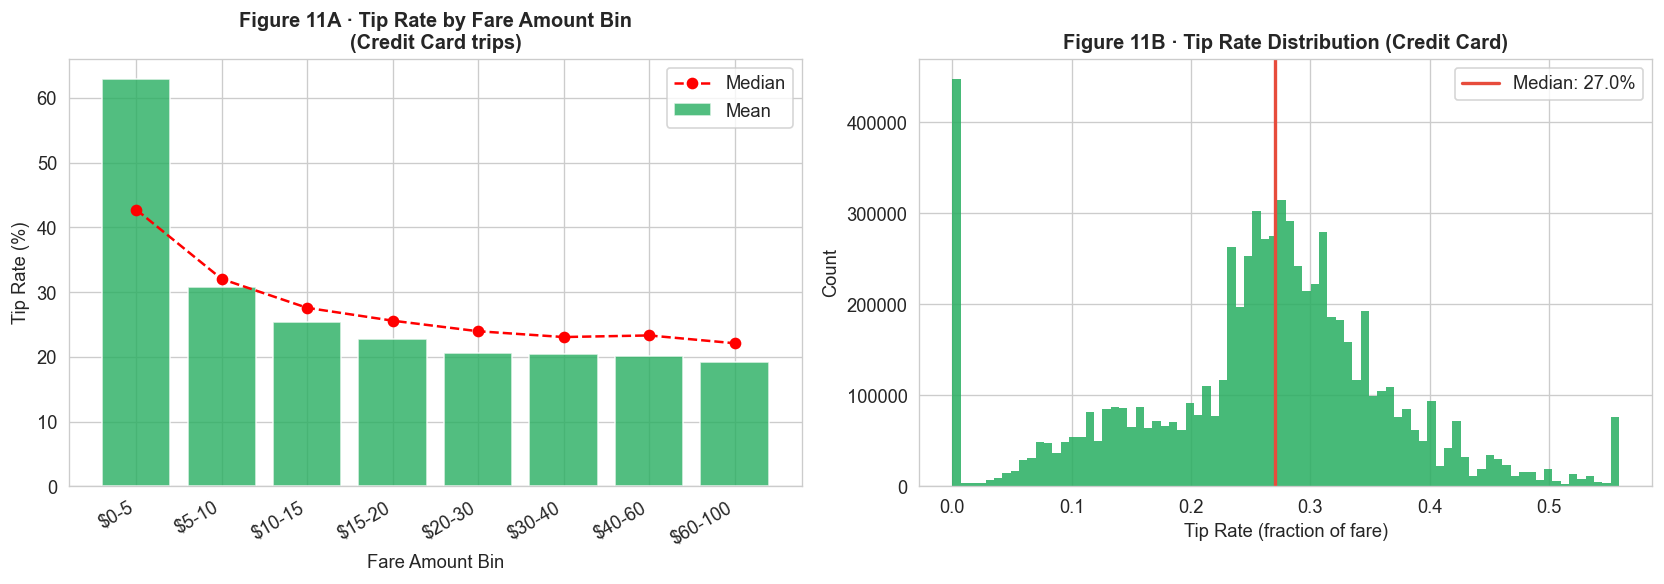

In [2]:
# Tip rate = tip_amount / fare_amount (credit card only)
cc = df[(df.payment_type == 1) & (df.fare_amount > 0)].copy()
cc['tip_rate'] = cc.tip_amount / cc.fare_amount
tip_rate_cap = cc.tip_rate.quantile(0.99)

# Fare bins
fare_bins = [0, 5, 10, 15, 20, 30, 40, 60, 100]
fare_labels_bin = ['$0-5','$5-10','$10-15','$15-20','$20-30','$30-40','$40-60','$60-100']
cc['fare_bin'] = pd.cut(cc.fare_amount, bins=fare_bins, labels=fare_labels_bin)

tip_by_fare = cc.groupby('fare_bin', observed=True)['tip_rate'].agg(['mean', 'median'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tip rate by fare bin
axes[0].bar(tip_by_fare.index, tip_by_fare['mean'] * 100,
            color='#27ae60', alpha=0.8, label='Mean', edgecolor='white')
axes[0].plot(range(len(tip_by_fare)), tip_by_fare['median'] * 100,
             'ro--', markersize=6, label='Median')
axes[0].set_xlabel('Fare Amount Bin')
axes[0].set_ylabel('Tip Rate (%)')
axes[0].set_title('Figure 11A · Tip Rate by Fare Amount Bin\n(Credit Card trips)')
axes[0].legend()
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Tip rate distribution (histogram)
tip_plot = cc['tip_rate'].clip(upper=tip_rate_cap)
axes[1].hist(tip_plot, bins=80, color='#27ae60', edgecolor='none', alpha=0.85)
axes[1].axvline(cc.tip_rate.median(), color='#e74c3c', lw=2,
                label=f'Median: {cc.tip_rate.median()*100:.1f}%')
axes[1].set_xlabel('Tip Rate (fraction of fare)')
axes[1].set_ylabel('Count')
axes[1].set_title('Figure 11B · Tip Rate Distribution (Credit Card)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 10. Bivariate Summary: Correlation Matrix

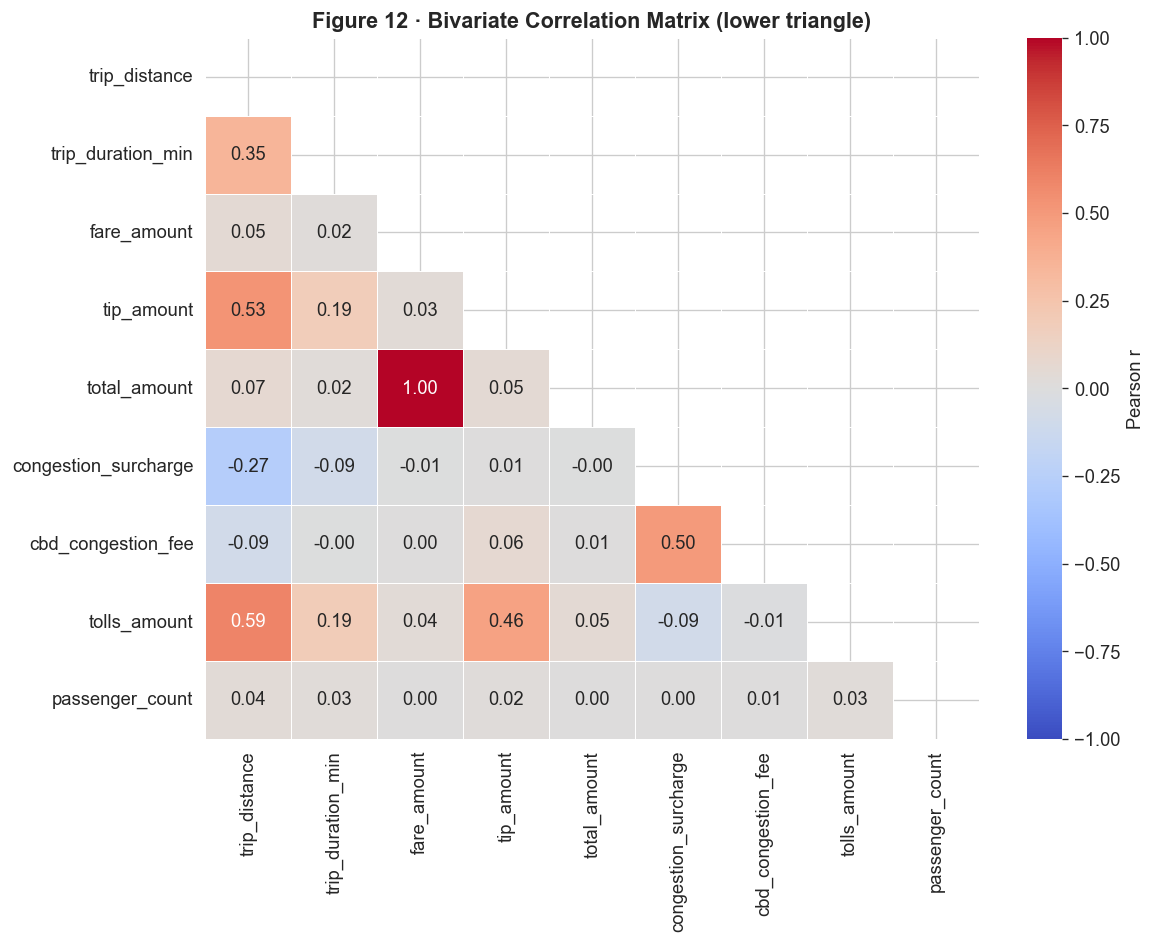

Key correlations:
  distance ↔ fare:     0.053
  distance ↔ total:    0.066
  duration ↔ fare:     0.021
  tip ↔ total:         0.054


In [3]:
corr_cols = ['trip_distance', 'trip_duration_min', 'fare_amount',
             'tip_amount', 'total_amount', 'congestion_surcharge',
             'cbd_congestion_fee', 'tolls_amount', 'passenger_count']

corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Figure 12 · Bivariate Correlation Matrix (lower triangle)', fontsize=13)
plt.tight_layout()
plt.show()

print('Key correlations:')
print(f'  distance ↔ fare:     {corr.loc["trip_distance","fare_amount"]:.3f}')
print(f'  distance ↔ total:    {corr.loc["trip_distance","total_amount"]:.3f}')
print(f'  duration ↔ fare:     {corr.loc["trip_duration_min","fare_amount"]:.3f}')
print(f'  tip ↔ total:         {corr.loc["tip_amount","total_amount"]:.3f}')